# Censo 2024 — Indicator exploration

Exploration of commune-level indicators from Chile's [2024 Population and Housing Census](https://censo2024.ine.gob.cl/resultados/). The data includes:

- **Electricity access** — Households with electricity (grid, solar, etc.)
- **Housing tenure** — Ownership vs renting
- **Employment by CAENES sector** — Share of employed persons (`sit_fuerza_trabajo = 1`) in each CAENES 1-digit letter (percent of comuna workforce)
- **Population** — Enumerated persons by comuna (`tipo_operativo = 2`, same census universe as other blocks; from full `personas_censo2024.csv`, this matches published-scale counts, not sample row counts)
- **Additional INE-only indicators (HIAP / feasibility bridges)** — all at comuna level, same universes as above where applicable:
  - `fixed_internet_household_share` — hogares `p15d_serv_internet_fija` (Sí / Sí+No denominator); technical scalability / digital infrastructure.
  - `employment_agriculture_forestry` — CAENES **A** (agriculture, forestry, fishing); AFOLU / NBS institutional capacity.
  - `employment_electricity_gas` — CAENES **D** (electricity, gas, steam); energy-supply institutional capacity.
  - `employment_water_waste` — CAENES **E** (water, sewage, waste); reserved for waste-family bridges (not in SR1.5 bridges yet).
  - `employment_construction` — CAENES **F**; buildings retrofit / contractor pool.
  - `employment_manufacturing` — CAENES **C**; industrial-efficiency institutional capacity.
  - `employment_mining` — CAENES **B**; exported for completeness (no SR1.5 bridge yet).
  - `employment_in_transport_and_logistics` — CAENES **H**; transport employment / institutional capacity.
  - `disability_prevalence` — persons `discapacidad` = Con discapacidad / (Con + Sin); inclusiveness / human capabilities.
  - `indigenous_identification_rate` — persons `p28_autoid_pueblo` = Sí / (Sí+No); public acceptance / cultural fit for AFOLU-type actions.
  - `literacy_rate` — persons `p37_alfabet` = Sí / (Sí+No); human capabilities (floor literacy).
  - `mean_years_schooling` — persons `escolaridad` (años de escolaridad, INE 0–24); mean by comuna among valid responses; human-capital / education stock.

CASEN-derived fields (e.g. Gini) are **not** included here by design.

In [11]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## 1. Full microdata → commune indicators

Official **Censo 2024** CSV extracts (`viviendas_censo2024.csv`, `hogares_censo2024.csv`, `personas_censo2024.csv`) in `../sample/` are read with DuckDB (`;` delimiter). Indicators are aggregated **by comuna** using the same universes as before (`tipo_operativo = 2`, etc.). The first run scans several GB and can take a few minutes.

**Employment:** each CAENES 1-digit letter is its own `employment_*` indicator (replaces bundled `industry_construction_employment` = B+C+F and `employment_agriculture_utilities` = A+D+E).

Small `*_sample.parquet` files remain useful for quick tests; this notebook targets the full files for production-style `raw_data`.

Source portal: [censo2024.ine.gob.cl/resultados](https://censo2024.ine.gob.cl/resultados/).

In [12]:
SAMPLE_DIR = "../sample"
# Full INE Censo 2024 microdata (semicolon-separated); large files — first run may take several minutes.
VIV_CSV = f"{SAMPLE_DIR}/viviendas_censo2024.csv"
HOG_CSV = f"{SAMPLE_DIR}/hogares_censo2024.csv"
PER_CSV = f"{SAMPLE_DIR}/personas_censo2024.csv"

# Read location dictionary with explicit column names (avoids CSV header/encoding issues)
loc_df = pd.read_csv(
    f"{SAMPLE_DIR}/dictionary_location.csv",
    usecols=[0, 1, 2],
    names=["codigo", "division", "nombre"],
    encoding="utf-8",
)
loc_df["nombre"] = loc_df["nombre"].str.strip()

con = duckdb.connect()
con.execute("SET threads TO 4")

# Register the preprocessed dataframe so DuckDB can use it
con.register("loc_df", loc_df)

_csv = "read_csv_auto(?, delim=';', header=true, ignore_errors=false)"
df = con.execute(
    f"""
WITH region_names AS (
  SELECT codigo AS region, nombre AS region_nombre FROM loc_df WHERE division = 'Región'
),
comuna_names AS (
  SELECT codigo AS comuna, nombre AS comuna_nombre FROM loc_df WHERE division = 'Comuna'
),
vivi AS (
  SELECT region, comuna,
    COUNT(*) FILTER (WHERE p9_fuente_elect IN (1,2,3,4,5)) * 100.0 / NULLIF(COUNT(*) FILTER (WHERE p9_fuente_elect IN (1,2,3,4,5,6)), 0) AS electricity_access_rate_pct
  FROM {_csv}
  WHERE tipo_operativo = 2 AND p3b_estado_ocupacion IN (1,2) AND p9_fuente_elect BETWEEN 1 AND 6
  GROUP BY region, comuna
),
hog AS (
  SELECT region, comuna,
    COUNT(*) FILTER (WHERE p12_tenencia_viv IN (1,2)) * 100.0 / NULLIF(COUNT(*), 0) AS home_ownership_pct,
    COUNT(*) FILTER (WHERE p12_tenencia_viv IN (3,4)) * 100.0 / NULLIF(COUNT(*), 0) AS renter_share_pct,
    COUNT(*) FILTER (WHERE p15d_serv_internet_fija = 1) * 100.0 / NULLIF(COUNT(*) FILTER (WHERE p15d_serv_internet_fija IN (1,2)), 0) AS fixed_internet_household_share_pct
  FROM {_csv}
  WHERE tipo_operativo = 2 AND p12_tenencia_viv IN (1,2,3,4,5,6,7,8,9)
  GROUP BY region, comuna
),
emp AS (
  SELECT region, comuna,
    COUNT(*) FILTER (WHERE cod_caenes = 'A') * 100.0 / NULLIF(COUNT(*), 0) AS employment_agriculture_forestry_pct,
    COUNT(*) FILTER (WHERE cod_caenes = 'B') * 100.0 / NULLIF(COUNT(*), 0) AS employment_mining_pct,
    COUNT(*) FILTER (WHERE cod_caenes = 'C') * 100.0 / NULLIF(COUNT(*), 0) AS employment_manufacturing_pct,
    COUNT(*) FILTER (WHERE cod_caenes = 'D') * 100.0 / NULLIF(COUNT(*), 0) AS employment_electricity_gas_pct,
    COUNT(*) FILTER (WHERE cod_caenes = 'E') * 100.0 / NULLIF(COUNT(*), 0) AS employment_water_waste_pct,
    COUNT(*) FILTER (WHERE cod_caenes = 'F') * 100.0 / NULLIF(COUNT(*), 0) AS employment_construction_pct,
    COUNT(*) FILTER (WHERE cod_caenes = 'H') * 100.0 / NULLIF(COUNT(*), 0) AS transport_logistics_pct
  FROM {_csv}
  WHERE tipo_operativo = 2 AND sit_fuerza_trabajo = 1
    AND cod_caenes IN ('A','B','C','D','E','F','G','H','I','J','K','L','M','N','O','P','Q','R','S','T','U')
  GROUP BY region, comuna
),
pers_soc AS (
  SELECT region, comuna,
    COUNT(*) FILTER (WHERE discapacidad = 1) * 100.0 / NULLIF(COUNT(*) FILTER (WHERE discapacidad IN (1,2)), 0) AS disability_prevalence_pct,
    COUNT(*) FILTER (WHERE p28_autoid_pueblo = 1) * 100.0 / NULLIF(COUNT(*) FILTER (WHERE p28_autoid_pueblo IN (1,2)), 0) AS indigenous_identification_rate_pct,
    COUNT(*) FILTER (WHERE p37_alfabet = 1) * 100.0 / NULLIF(COUNT(*) FILTER (WHERE p37_alfabet IN (1,2)), 0) AS literacy_rate_pct,
    AVG(escolaridad) FILTER (WHERE escolaridad BETWEEN 0 AND 24) AS mean_years_schooling
  FROM {_csv}
  WHERE tipo_operativo = 2
  GROUP BY region, comuna
),
pop AS (
  SELECT region, comuna, COUNT(*) AS population
  FROM {_csv}
  WHERE tipo_operativo = 2
  GROUP BY region, comuna
),
joined AS (
  SELECT
    COALESCE(v.region, h.region, e.region, p.region, s.region) AS region,
    COALESCE(v.comuna, h.comuna, e.comuna, p.comuna, s.comuna) AS comuna,
    ROUND(v.electricity_access_rate_pct, 2) AS electricity_access_rate_pct,
    ROUND(h.home_ownership_pct, 2) AS home_ownership_pct,
    ROUND(h.renter_share_pct, 2) AS renter_share_pct,
    ROUND(h.fixed_internet_household_share_pct, 2) AS fixed_internet_household_share_pct,
    ROUND(e.employment_agriculture_forestry_pct, 2) AS employment_agriculture_forestry_pct,
    ROUND(e.employment_mining_pct, 2) AS employment_mining_pct,
    ROUND(e.employment_manufacturing_pct, 2) AS employment_manufacturing_pct,
    ROUND(e.employment_electricity_gas_pct, 2) AS employment_electricity_gas_pct,
    ROUND(e.employment_water_waste_pct, 2) AS employment_water_waste_pct,
    ROUND(e.employment_construction_pct, 2) AS employment_construction_pct,
    ROUND(e.transport_logistics_pct, 2) AS transport_logistics_pct,
    p.population AS population,
    ROUND(s.disability_prevalence_pct, 2) AS disability_prevalence_pct,
    ROUND(s.indigenous_identification_rate_pct, 2) AS indigenous_identification_rate_pct,
    ROUND(s.literacy_rate_pct, 2) AS literacy_rate_pct,
    ROUND(s.mean_years_schooling, 2) AS mean_years_schooling
  FROM vivi v
  FULL OUTER JOIN hog h ON v.region = h.region AND v.comuna = h.comuna
  FULL OUTER JOIN emp e ON COALESCE(v.region, h.region) = e.region AND COALESCE(v.comuna, h.comuna) = e.comuna
  FULL OUTER JOIN pop p ON COALESCE(v.region, h.region, e.region) = p.region AND COALESCE(v.comuna, h.comuna, e.comuna) = p.comuna
  FULL OUTER JOIN pers_soc s ON COALESCE(v.region, h.region, e.region, p.region) = s.region AND COALESCE(v.comuna, h.comuna, e.comuna, p.comuna) = s.comuna
),
with_names AS (
  SELECT j.*, rn.region_nombre, cn.comuna_nombre
  FROM joined j
  LEFT JOIN region_names rn ON j.region = rn.region
  LEFT JOIN comuna_names cn ON j.comuna = cn.comuna
)
SELECT region, comuna, region_nombre, comuna_nombre, attribute_type, attribute_value, attribute_units FROM (
  SELECT region, comuna, region_nombre, comuna_nombre, 'electricity_access_rate' AS attribute_type, electricity_access_rate_pct AS attribute_value, 'percent' AS attribute_units FROM with_names WHERE electricity_access_rate_pct IS NOT NULL
  UNION ALL
  SELECT region, comuna, region_nombre, comuna_nombre, 'home_ownership', home_ownership_pct, 'percent' FROM with_names WHERE home_ownership_pct IS NOT NULL
  UNION ALL
  SELECT region, comuna, region_nombre, comuna_nombre, 'renter_share', renter_share_pct, 'percent' FROM with_names WHERE renter_share_pct IS NOT NULL
  UNION ALL
  SELECT region, comuna, region_nombre, comuna_nombre, 'employment_agriculture_forestry', employment_agriculture_forestry_pct, 'percent' FROM with_names WHERE employment_agriculture_forestry_pct IS NOT NULL
  UNION ALL
  SELECT region, comuna, region_nombre, comuna_nombre, 'employment_mining', employment_mining_pct, 'percent' FROM with_names WHERE employment_mining_pct IS NOT NULL
  UNION ALL
  SELECT region, comuna, region_nombre, comuna_nombre, 'employment_manufacturing', employment_manufacturing_pct, 'percent' FROM with_names WHERE employment_manufacturing_pct IS NOT NULL
  UNION ALL
  SELECT region, comuna, region_nombre, comuna_nombre, 'employment_electricity_gas', employment_electricity_gas_pct, 'percent' FROM with_names WHERE employment_electricity_gas_pct IS NOT NULL
  UNION ALL
  SELECT region, comuna, region_nombre, comuna_nombre, 'employment_water_waste', employment_water_waste_pct, 'percent' FROM with_names WHERE employment_water_waste_pct IS NOT NULL
  UNION ALL
  SELECT region, comuna, region_nombre, comuna_nombre, 'employment_construction', employment_construction_pct, 'percent' FROM with_names WHERE employment_construction_pct IS NOT NULL
  UNION ALL
  SELECT region, comuna, region_nombre, comuna_nombre, 'employment_in_transport_and_logistics', transport_logistics_pct, 'percent' FROM with_names WHERE transport_logistics_pct IS NOT NULL
  UNION ALL
  SELECT region, comuna, region_nombre, comuna_nombre, 'population', CAST(population AS DOUBLE), 'persons' FROM with_names WHERE population IS NOT NULL
  UNION ALL
  SELECT region, comuna, region_nombre, comuna_nombre, 'fixed_internet_household_share', fixed_internet_household_share_pct, 'percent' FROM with_names WHERE fixed_internet_household_share_pct IS NOT NULL
  UNION ALL
  SELECT region, comuna, region_nombre, comuna_nombre, 'disability_prevalence', disability_prevalence_pct, 'percent' FROM with_names WHERE disability_prevalence_pct IS NOT NULL
  UNION ALL
  SELECT region, comuna, region_nombre, comuna_nombre, 'indigenous_identification_rate', indigenous_identification_rate_pct, 'percent' FROM with_names WHERE indigenous_identification_rate_pct IS NOT NULL
  UNION ALL
  SELECT region, comuna, region_nombre, comuna_nombre, 'literacy_rate', literacy_rate_pct, 'percent' FROM with_names WHERE literacy_rate_pct IS NOT NULL
  UNION ALL
  SELECT region, comuna, region_nombre, comuna_nombre, 'mean_years_schooling', mean_years_schooling, 'years' FROM with_names WHERE mean_years_schooling IS NOT NULL
)
ORDER BY region, comuna, attribute_type
""",
    [VIV_CSV, HOG_CSV, PER_CSV, PER_CSV, PER_CSV],
).df()

df

,region,comuna,region_nombre,comuna_nombre,attribute_type,attribute_value,attribute_units
0,1,1101,Tarapacá,Iquique,disability_prevalence,8.59,percent
1,1,1101,Tarapacá,Iquique,electricity_access_rate,99.75,percent
2,1,1101,Tarapacá,Iquique,employment_agriculture_forestry,1.19,percent
3,1,1101,Tarapacá,Iquique,employment_construction,5.54,percent
4,1,1101,Tarapacá,Iquique,employment_electricity_gas,0.60,percent
...,...,...,...,...,...,...,...
5515,16,16305,Ñuble,San Nicolás,indigenous_identification_rate,4.84,percent
5516,16,16305,Ñuble,San Nicolás,literacy_rate,92.32,percent
5517,16,16305,Ñuble,San Nicolás,mean_years_schooling,8.88,years
5518,16,16305,Ñuble,San Nicolás,population,15082.00,persons


In [13]:
labels = ["very low", "low", "medium", "high", "very high"]
df["attribute_category"] = df.groupby("attribute_type")["attribute_value"].transform(
    lambda s: pd.qcut(s, 5, labels=False, duplicates="drop").map(lambda i: labels[min(i, 4)])
    if s.nunique() > 1 else "medium"
)
df.head(5)

,region,comuna,region_nombre,comuna_nombre,attribute_type,attribute_value,attribute_units,attribute_category
0,1,1101,Tarapacá,Iquique,disability_prevalence,8.59,percent,very low
1,1,1101,Tarapacá,Iquique,electricity_access_rate,99.75,percent,high
2,1,1101,Tarapacá,Iquique,employment_agriculture_forestry,1.19,percent,very low
3,1,1101,Tarapacá,Iquique,employment_construction,5.54,percent,very low
4,1,1101,Tarapacá,Iquique,employment_electricity_gas,0.60,percent,very low


In [14]:
df.to_csv("../data/raw_data_cl_ine_censo.csv", index=False)

## 2. Curated data analysis

The exported `raw_data_cl_ine_censo.csv` (under `../data/`) contains aggregated results by commune from the **full** census CSVs. Below are the distributions for each indicator.

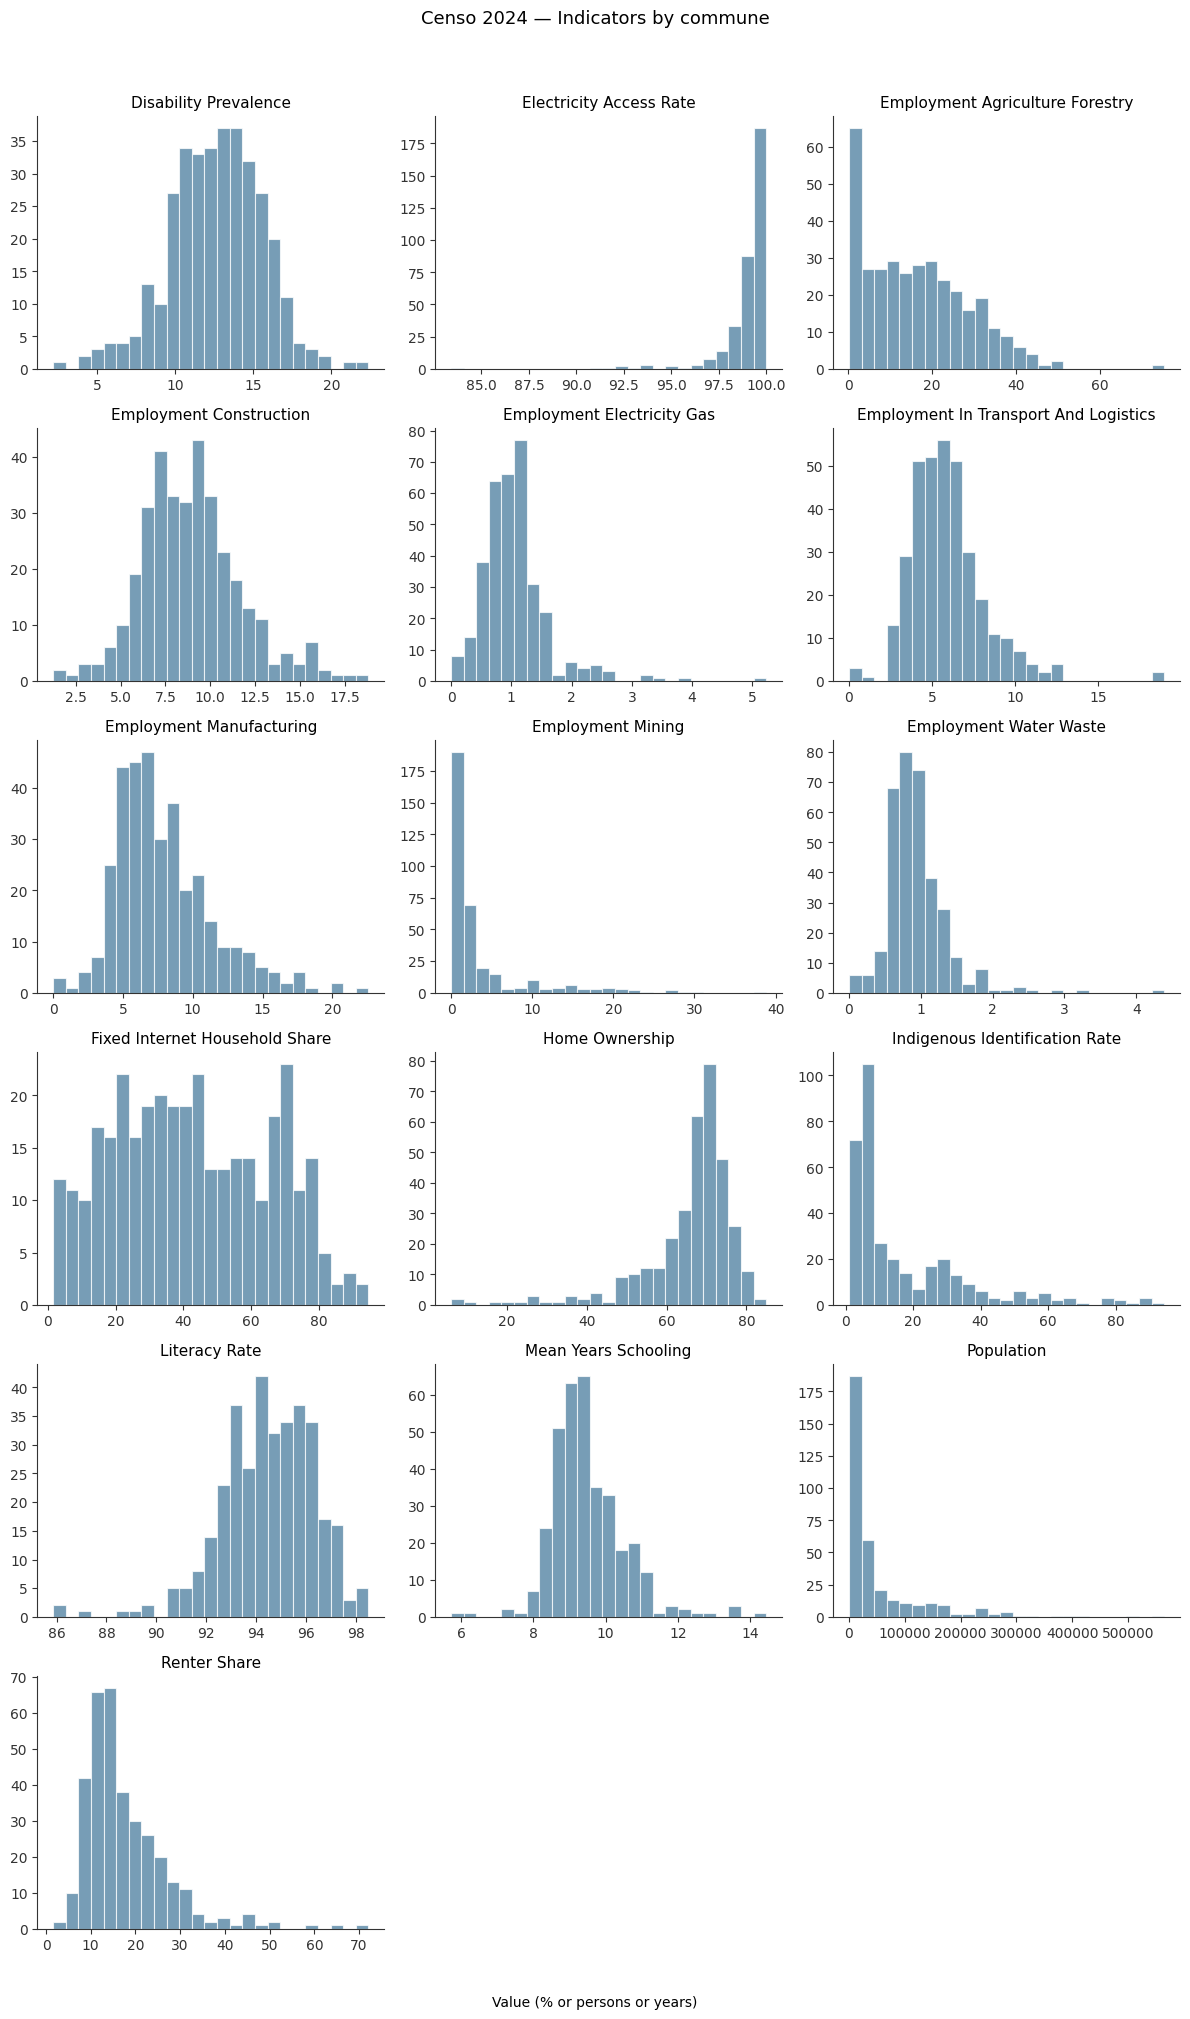

In [15]:
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw_data_cl_ine_censo.csv")

# Minimal style
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#333",
    "axes.linewidth": 0.8,
    "grid.color": "#e0e0e0",
    "grid.alpha": 0.7,
    "xtick.color": "#333",
    "ytick.color": "#333",
    "font.size": 10,
})

attrs = sorted(df["attribute_type"].unique())
ncols = 3
nrows = math.ceil(len(attrs) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.2 * nrows))
axes = np.atleast_1d(axes).ravel()
for i, attr in enumerate(attrs):
    ax = axes[i]
    data = df.loc[df["attribute_type"] == attr, "attribute_value"]
    ax.hist(data, bins=25, color="#4a7c9e", alpha=0.75, edgecolor="white", linewidth=0.8)
    ax.set_title(attr.replace("_", " ").title(), fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x)}"))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
for j in range(len(attrs), len(axes)):
    axes[j].axis("off")

fig.suptitle("Censo 2024 — Indicators by commune", fontsize=13, y=1.02)
fig.text(0.5, -0.02, "Value (% or persons or years)", ha="center", fontsize=10)
plt.tight_layout()
plt.show()